<a href="https://colab.research.google.com/github/namirachmi08/Pre-Processing-Data/blob/main/Pre-Processing_Deskripsi%20Buku.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kelas 2025C

Nama Anggota Kelompok:

Namira Rachmi Andini (Nim 25031554153)

Syahira Nanda Raihanna (Nim 25031554199)

# Chapter 4 - Text Pre-processing Data Books to Scrape

In [ ]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

import pandas as pd
import re
import string
import nltk
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
data = []

In [ ]:
base_url = "https://books.toscrape.com/"

data = []

for page in range(1, 51):
    if page == 1:
        url = base_url
    else:
        url = f"{base_url}catalogue/page-{page}.html"

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    books = soup.find_all("article", class_="product_pod")

    for book in books:
        title = book.h3.a.get("title", "")

        detail_url = urljoin(url, book.h3.a.get("href", ""))

        detail_response = requests.get(detail_url)
        detail_soup = BeautifulSoup(detail_response.text, "html.parser")

        description = ""

        description_tag = detail_soup.find("div", id="product_description")

        if description_tag:
            description_p = description_tag.find_next_sibling("p")

            if description_p:
                description = description_p.get_text(" ", strip=True)

        data.append([title, description])

df = pd.DataFrame(data, columns=["Title", "Description"])

print("Jumlah data:", len(df))

Jumlah data: 1000


In [ ]:
def remove_repeated_text(text):
    text = str(text).strip()

    words = text.split()

    # Cari pola pengulangan dengan panjang minimal 10 kata
    for n in range(min(100, len(words) // 2), 9, -1):
        first_part = words[:n]

        for start in range(n, len(words) - n + 1):
            if words[start:start+n] == first_part:
                # Hapus bagian yang berulang
                words = words[:start] + words[start+n:]
                return " ".join(words)

    return text

df["Description"] = df["Description"].apply(remove_repeated_text)

In [ ]:
print(df.loc[0, "Description"].count(
    "It's hard to imagine a world without A Light in the Attic."
))

1


## Membuat Data Teks

Hanya deskripsi yang digunakan untuk proses text preprocessing.

In [ ]:
# 1. Membuat data teks dari Description saja

df["Text"] = df["Description"].fillna("").astype(str)
df["Text_Clean"] = df["Text"]

display(df[["Text", "Text_Clean"]].head())

,Text,Text_Clean
0,It's hard to imagine a world without A Light i...,It's hard to imagine a world without A Light i...
1,"""Erotic and absorbing...Written with starling ...","""Erotic and absorbing...Written with starling ..."
2,"Dans une France assez proche de la nÃ´tre, un ...","Dans une France assez proche de la nÃ´tre, un ..."
3,"WICKED above her hipbone, GIRL across her hear...","WICKED above her hipbone, GIRL across her hear..."
4,From a renowned historian comes a groundbreaki...,From a renowned historian comes a groundbreaki...


## WordCloud Sebelum Text Pre-processing

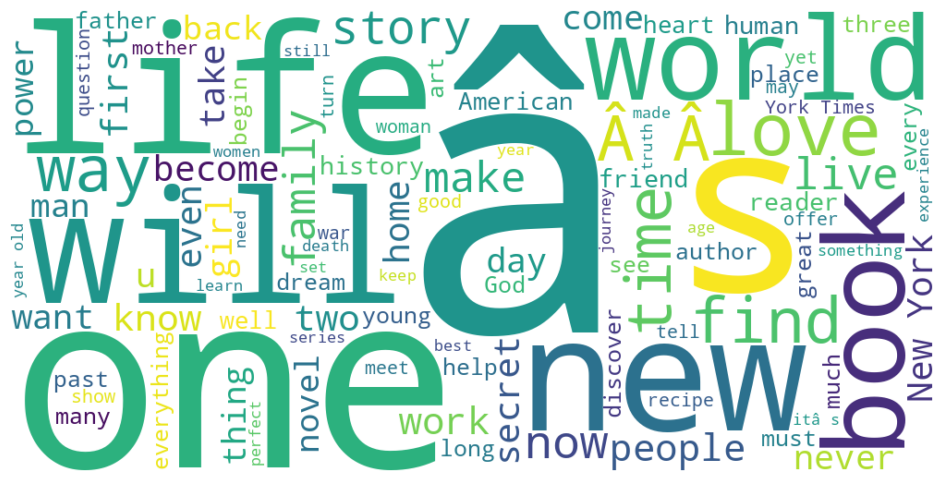

In [ ]:
text_raw = " ".join(df["Text"].dropna().astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(text_raw)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

## 1. Remove HTML Tags

Menghapus tag HTML yang masih terdapat pada teks jika ada.

In [ ]:
def remove_html(text):
    return re.sub(r'<.*?>', '', str(text))

df["Text_Clean"] = df["Text"].apply(remove_html)
df[["Text", "Text_Clean"]].head(100)

,Text,Text_Clean
0,It's hard to imagine a world without A Light i...,It's hard to imagine a world without A Light i...
1,"""Erotic and absorbing...Written with starling ...","""Erotic and absorbing...Written with starling ..."
2,"Dans une France assez proche de la nÃ´tre, un ...","Dans une France assez proche de la nÃ´tre, un ..."
3,"WICKED above her hipbone, GIRL across her hear...","WICKED above her hipbone, GIRL across her hear..."
4,From a renowned historian comes a groundbreaki...,From a renowned historian comes a groundbreaki...
...,...,...
95,This New York Times Bestselling series continu...,This New York Times Bestselling series continu...
96,Itâs time to venture beyond vanilla and choc...,Itâs time to venture beyond vanilla and choc...
97,"Displaying the most impressive throws, compell...","Displaying the most impressive throws, compell..."
98,What if you could live multiple lives simultan...,What if you could live multiple lives simultan...


## 2. Lower Casing

Mengubah seluruh huruf menjadi huruf kecil agar kata yang sama dengan perbedaan kapitalisasi dianggap sebagai kata yang sama.

In [ ]:
df["Text_Clean"] = df["Text_Clean"].str.lower()
df[["Text", "Text_Clean"]].head(100)

,Text,Text_Clean
0,It's hard to imagine a world without A Light i...,it's hard to imagine a world without a light i...
1,"""Erotic and absorbing...Written with starling ...","""erotic and absorbing...written with starling ..."
2,"Dans une France assez proche de la nÃ´tre, un ...","dans une france assez proche de la nã´tre, un ..."
3,"WICKED above her hipbone, GIRL across her hear...","wicked above her hipbone, girl across her hear..."
4,From a renowned historian comes a groundbreaki...,from a renowned historian comes a groundbreaki...
...,...,...
95,This New York Times Bestselling series continu...,this new york times bestselling series continu...
96,Itâs time to venture beyond vanilla and choc...,itâs time to venture beyond vanilla and choc...
97,"Displaying the most impressive throws, compell...","displaying the most impressive throws, compell..."
98,What if you could live multiple lives simultan...,what if you could live multiple lives simultan...


## 3. Remove Punctuation

Menghapus tanda baca seperti titik, koma, tanda seru, tanda tanya, dan tanda baca lainnya.

In [ ]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df["Text_Clean"] = df["Text_Clean"].apply(remove_punctuation)
df[["Text", "Text_Clean"]].head(100)

,Text,Text_Clean
0,It's hard to imagine a world without A Light i...,its hard to imagine a world without a light in...
1,"""Erotic and absorbing...Written with starling ...",erotic and absorbingwritten with starling powe...
2,"Dans une France assez proche de la nÃ´tre, un ...",dans une france assez proche de la nã´tre un h...
3,"WICKED above her hipbone, GIRL across her hear...",wicked above her hipbone girl across her heart...
4,From a renowned historian comes a groundbreaki...,from a renowned historian comes a groundbreaki...
...,...,...
95,This New York Times Bestselling series continu...,this new york times bestselling series continu...
96,Itâs time to venture beyond vanilla and choc...,itâs time to venture beyond vanilla and choc...
97,"Displaying the most impressive throws, compell...",displaying the most impressive throws compelli...
98,What if you could live multiple lives simultan...,what if you could live multiple lives simultan...


## 4. Remove Numbers

Menghapus angka yang terdapat dalam teks.

In [ ]:
def remove_numbers(text):
    return re.sub(r'\d+', '', str(text))

df["Text_Clean"] = df["Text_Clean"].apply(remove_numbers)
df[["Text", "Text_Clean"]].head(100)

,Text,Text_Clean
0,It's hard to imagine a world without A Light i...,its hard to imagine a world without a light in...
1,"""Erotic and absorbing...Written with starling ...",erotic and absorbingwritten with starling powe...
2,"Dans une France assez proche de la nÃ´tre, un ...",dans une france assez proche de la nã´tre un h...
3,"WICKED above her hipbone, GIRL across her hear...",wicked above her hipbone girl across her heart...
4,From a renowned historian comes a groundbreaki...,from a renowned historian comes a groundbreaki...
...,...,...
95,This New York Times Bestselling series continu...,this new york times bestselling series continu...
96,Itâs time to venture beyond vanilla and choc...,itâs time to venture beyond vanilla and choc...
97,"Displaying the most impressive throws, compell...",displaying the most impressive throws compelli...
98,What if you could live multiple lives simultan...,what if you could live multiple lives simultan...


## 5. Remove Extra Spaces

Menghapus spasi berlebih sehingga teks menjadi lebih rapi.

In [ ]:
def remove_extra_spaces(text):
    return re.sub(r'\s+', ' ', text).strip()

df["Text_Clean"] = df["Text_Clean"].apply(remove_extra_spaces)
df[["Text", "Text_Clean"]].head(100)

,Text,Text_Clean
0,It's hard to imagine a world without A Light i...,its hard to imagine a world without a light in...
1,"""Erotic and absorbing...Written with starling ...",erotic and absorbingwritten with starling powe...
2,"Dans une France assez proche de la nÃ´tre, un ...",dans une france assez proche de la nã´tre un h...
3,"WICKED above her hipbone, GIRL across her hear...",wicked above her hipbone girl across her heart...
4,From a renowned historian comes a groundbreaki...,from a renowned historian comes a groundbreaki...
...,...,...
95,This New York Times Bestselling series continu...,this new york times bestselling series continu...
96,Itâs time to venture beyond vanilla and choc...,itâs time to venture beyond vanilla and choc...
97,"Displaying the most impressive throws, compell...",displaying the most impressive throws compelli...
98,What if you could live multiple lives simultan...,what if you could live multiple lives simultan...


## 6. Removal of Emojis

menghapus emoji pada judul maupun deskripsi buku jika ada

In [ ]:
!pip install demoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 3.0 MB/s eta 0:00:00


In [ ]:
import demoji
# demoji.download_codes() # Download emoji codes (run once)

def remove_emoji(text):
    cleaned_text = demoji.replace(text, repl="")
    return cleaned_text

df["Text_Clean"] = df["Text_Clean"].apply(remove_emoji)
df[["Text", "Text_Clean"]].head(100)

,Text,Text_Clean
0,It's hard to imagine a world without A Light i...,its hard to imagine a world without a light in...
1,"""Erotic and absorbing...Written with starling ...",erotic and absorbingwritten with starling powe...
2,"Dans une France assez proche de la nÃ´tre, un ...",dans une france assez proche de la nã´tre un h...
3,"WICKED above her hipbone, GIRL across her hear...",wicked above her hipbone girl across her heart...
4,From a renowned historian comes a groundbreaki...,from a renowned historian comes a groundbreaki...
...,...,...
95,This New York Times Bestselling series continu...,this new york times bestselling series continu...
96,Itâs time to venture beyond vanilla and choc...,itâs time to venture beyond vanilla and choc...
97,"Displaying the most impressive throws, compell...",displaying the most impressive throws compelli...
98,What if you could live multiple lives simultan...,what if you could live multiple lives simultan...


## 7. Remove Stopwords

Menghapus kata-kata umum dalam bahasa Inggris yang kurang memberikan informasi penting terhadap isi teks.

In [ ]:
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

df["Text_Clean"] = df["Text_Clean"].apply(remove_stopwords)

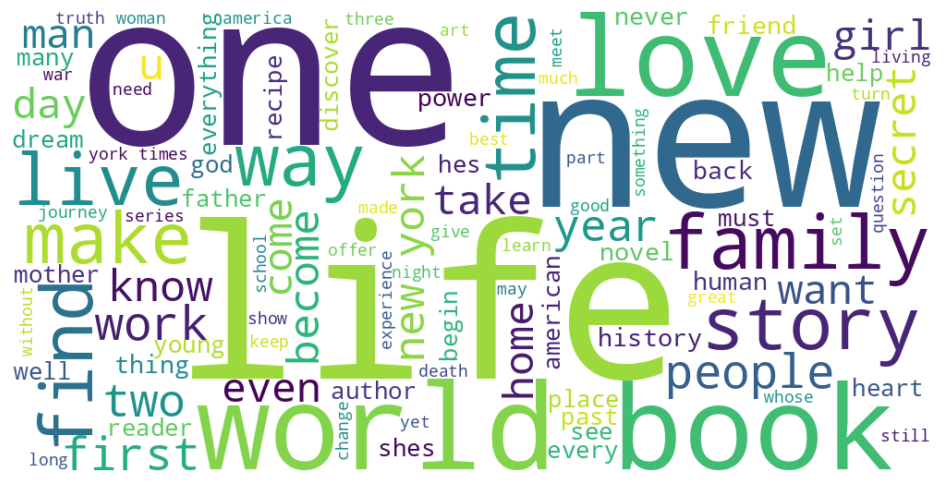

In [ ]:
text_middle = " ".join(df["Text_Clean"].dropna().astype(str))

wordcloud = WordCloud(width=1000, height=500, background_color="white", max_words=100).generate(text_middle)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
words_middle = text_middle.split()

frequent_words_2 = Counter(words_middle).most_common(20)
frequent_words_2

[('new', 680),
 ('one', 639),
 ('life', 548),
 ('world', 415),
 ('book', 398),
 ('love', 381),
 ('time', 329),
 ('story', 310),
 ('first', 281),
 ('years', 272),
 ('way', 244),
 ('family', 241),
 ('us', 235),
 ('like', 234),
 ('find', 215),
 ('people', 212),
 ('two', 210),
 ('author', 197),
 ('also', 192),
 ('york', 187)]

## 7. Stemming

Mengubah kata menjadi bentuk dasar atau bentuk stem dengan menggunakan Porter Stemmer.

In [ ]:
def stemming(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

df["Text_Clean"] = df["Text_Clean"].apply(stemming)
display(df[["Text", "Text_Clean"]].head())

,Text,Text_Clean
0,It's hard to imagine a world without A Light i...,hard imagin world without light collect poetri...
1,"""Erotic and absorbing...Written with starling ...",erot new york time book review king oyster gir...
2,"Dans une France assez proche de la nÃ´tre, un ...",dan une franc de la un dan la motiv par une ca...
3,"WICKED above her hipbone, GIRL across her hear...",wick girl across heart word like road map repo...
4,From a renowned historian comes a groundbreaki...,renown historian come groundbreak narr human c...


## 8. Removal of Rare words

menghapus kata yang terlalu sering muncul dalam dataset karena dianggap kurang informatif.

In [ ]:
from collections import Counter

# Hitung frekuensi setiap kata
all_words = ' '.join(df["Text_Clean"]).split()
word_freq = Counter(all_words)

# Kata yang hanya muncul 1 kali
rare_words = {word for word, freq in word_freq.items() if freq == 1}

print("Jumlah rare words:", len(rare_words))

Jumlah rare words: 8664


In [ ]:
rare_words = {word for word, freq in word_freq.items() if freq <= 2}

print("Jumlah rare words:", len(rare_words))

Jumlah rare words: 10792


In [ ]:
def remove_rare_words(text):
    return " ".join(
        word for word in text.split()
        if word not in rare_words)

df["Text_Clean"] = df["Text_Clean"].apply(remove_rare_words)
df[["Text", "Text_Clean"]].head(10)

,Text,Text_Clean
0,It's hard to imagine a world without A Light i...,hard imagin world without light collect poetri...
1,"""Erotic and absorbing...Written with starling ...",erot new york time book review king oyster gir...
2,"Dans une France assez proche de la nÃ´tre, un ...",dan une franc de la un dan la motiv par une ca...
3,"WICKED above her hipbone, GIRL across her hear...",wick girl across heart word like road map repo...
4,From a renowned historian comes a groundbreaki...,renown historian come groundbreak narr human c...
5,Patient Twenty-nine.A monster roams the halls ...,patient monster roam hall sooth hill asylum th...
6,Drawing on his extensive experience evaluating...,draw extens experi evalu applic market agenc f...
7,"""If you have a heart, if you have a soul, Kare...",heart soul karen come woman make fall love vic...
8,For readers of Laura Hillenbrand's Seabiscuit ...,reader laura unbroken dramat stori american ro...
9,"Praise for Aracelis Girmay:""[Girmay's] every l...",prais everi call yearn connect across time pla...


## *TEKS AKHIR*

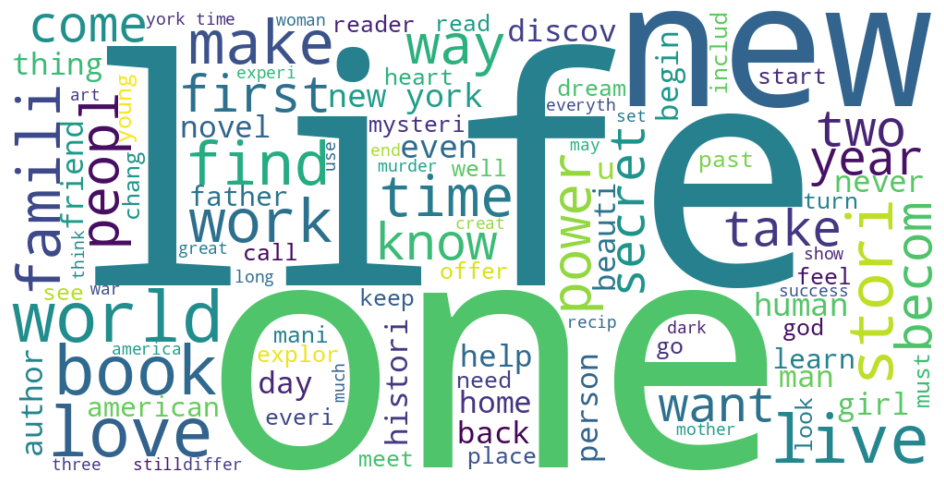

In [ ]:
text_final = " ".join(df["Text_Clean"].dropna().astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100).generate(text_final)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
display(df[["Text", "Text_Clean"]].head(100))

,Text,Text_Clean
0,It's hard to imagine a world without A Light i...,hard imagin world without light collect poetri...
1,"""Erotic and absorbing...Written with starling ...",erot new york time book review king oyster gir...
2,"Dans une France assez proche de la nÃ´tre, un ...",dan une franc de la un dan la motiv par une ca...
3,"WICKED above her hipbone, GIRL across her hear...",wick girl across heart word like road map repo...
4,From a renowned historian comes a groundbreaki...,renown historian come groundbreak narr human c...
...,...,...
95,This New York Times Bestselling series continu...,new york time bestsel seri continu jo april ma...
96,Itâs time to venture beyond vanilla and choc...,time ventur beyond vanilla chocol take bake sk...
97,"Displaying the most impressive throws, compell...",display impress throw compel domin pin decis j...
98,What if you could live multiple lives simultan...,could live multipl live simultan constant perf...


In [ ]:
df[["Title", "Description", "Text", "Text_Clean"]].head(100).isnull().sum() #cek missing value

,0
Title,0
Description,0
Text,0
Text_Clean,0


In [ ]:
df.duplicated().head(100).sum() #cek data duplikat

np.int64(0)

In [ ]:
# ekspor data
df.head(100).to_excel("books_text_preprocessing.xlsx", index=False)
print("File berhasil disimpan.")

File berhasil disimpan.
